# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [1]:
%pip install "geotessera==0.8.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.6/146.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [3]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 

    The import of 'shiny' bindings from the root level will be deactivated in a future version.
    Until then, set log level to 'ERROR' to suppress this warning.



Connect to your Google Drive to load your dataset within your drive.

In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Load your geospatial dataset.

In [5]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2018.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2018.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [6]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

2549

In [7]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

2549

Combine the datasets

In [8]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [9]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [10]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [11]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2018 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2018

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((48021.391 175995.648, 48122.20...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((51095.901 171868.622, 51083.21...",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((51005.99 171890.209, 51008.424...",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((50994.83 171884.82, 50994.869 ...",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,"MULTIPOLYGON (((50952.172 171875.47, 50951.34 ...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((158198.594 164931.746, 158198....",fs + fs°,189,hab
18092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((184116.994 189935.256, 184110....",ppmb + prus,186,gh
4469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((169016.456 165510.586, 169015....",bl,185,gh
17056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((129803.645 157167.153, 129791....",uv + kbgml,184,gh


Convert multipolygon to points.

In [12]:
datagrassbwk2018["geometry"] = datagrassbwk2018.geometry.centroid
datagrassbwk2018

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (48016.779 175782.374),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (51088.129 171893.452),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (51029.806 171897.777),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (50996.272 171885.691),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F1_2,F1_2,F1_2,F1_2,1.0,POINT (50951.405 171878.196),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (158470.26 165287.134),fs + fs°,189,hab
18092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (184164.934 189981.224),ppmb + prus,186,gh
4469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (169059.077 165684.85),bl,185,gh
17056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (129830.011 157199.806),uv + kbgml,184,gh


<Axes: >

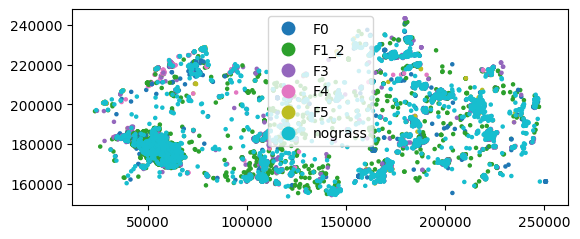

In [13]:
datagrassbwk2018.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [14]:
from geotessera import GeoTessera
import numpy as np
from geotessera.store import GeoTesseraZarr

#gt = GeoTessera(dataset_version='v1.1', dataset_variant='cambridge')

In [15]:
points = datagrassbwk2018.to_crs("EPSG:4326")
points = points[["Level4","geometry"]]
points

,Level4,geometry
0,F0,POINT (2.91943 50.88345)
1,F1_2,POINT (2.96412 50.84903)
2,F1_2,POINT (2.96329 50.84906)
3,F1_2,POINT (2.96281 50.84894)
4,F1_2,POINT (2.96218 50.84887)
...,...,...
4667,nograss,POINT (4.4889 50.79798)
18092,nograss,POINT (4.85566 51.01902)
4469,nograss,POINT (4.63912 50.80131)
17056,nograss,POINT (4.08309 50.72499)


In [16]:
from geotessera.store import GeoTesseraZarr

gt = GeoTesseraZarr()
print(gt.years)  # [2017, 2018, ..., 2025]


[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [17]:
coords = [(geom.x, geom.y) for geom in points.geometry]

gt = GeoTesseraZarr()
print(gt.years)  # [2017, 2018, ..., 2025]

# Sample embeddings at specific points (no download needed)
X = gt.sample_points(coords, year=2018)
print(f"Shape: {X.shape}")



Output()

[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


Shape: (11046, 128)


In [18]:
X

array([[ 2.482271  ,  0.9118546 , -1.8743678 , ...,  0.20263436,
         2.5329297 , -2.330295  ],
       [ 6.9143443 ,  0.43554926, -0.97998583, ...,  2.6677392 ,
         4.137718  ,  1.4155351 ],
       [ 4.1041503 , -0.20267409,  1.9254038 , ...,  1.064039  ,
         1.8240669 ,  1.1653761 ],
       ...,
       [ 4.63407   ,  0.47938657,  1.5979552 , ..., -1.7577507 ,
         2.9295845 ,  1.1718338 ],
       [ 7.3461266 , -0.05784352,  1.330401  , ...,  0.05784352,
         2.7186453 , -0.05784352],
       [ 3.6429381 , -0.14970979,  1.4970978 , ..., -3.992261  ,
         4.940423  ,  2.4452598 ]], dtype=float32)

In [19]:
import pandas as pd

# Convert embeddings to DataFrame
emb_df = pd.DataFrame(
    X,
    columns=[f"emb_{i}" for i in range(X.shape[1])]
)

# Keep desired columns from GeoDataFrame
out = pd.concat(
    [
        points[["Level4"]].reset_index(drop=True),
        points.geometry.x.rename("lon").reset_index(drop=True),
        points.geometry.y.rename("lat").reset_index(drop=True),
        emb_df
    ],
    axis=1
)

out

,Level4,lon,lat,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,F0,2.919434,50.883453,2.482271,0.911855,-1.874368,2.380954,2.634247,1.418441,-3.546101,...,-2.988857,-6.079031,-1.519758,-3.495443,0.151976,-0.303952,-4.761908,0.202634,2.532930,-2.330295
1,F1_2,2.964116,50.849030,6.914344,0.435549,-0.979986,2.341077,1.088873,-3.429950,-5.607697,...,-3.157732,-5.825471,-4.028831,-4.301049,0.435549,0.871099,-1.197760,2.667739,4.137718,1.415535
2,F1_2,2.963287,50.849059,4.104150,-0.202674,1.925404,0.354680,0.050669,-3.445460,-1.874735,...,-1.317382,-3.698802,-4.053482,-6.434902,2.077410,-2.026741,-5.016184,1.064039,1.824067,1.165376
3,F1_2,2.962814,50.848945,2.988500,-2.265476,0.915831,3.374113,1.831661,-2.217274,-0.241008,...,-0.674823,-3.904331,-2.651089,-3.422315,2.313678,-1.831661,-2.169073,1.060436,4.193541,1.687057
4,F1_2,2.962179,50.848870,2.760218,-0.942514,-0.403934,3.298797,1.144481,-3.029508,-1.817705,...,-3.029508,-8.549944,-4.914535,-3.568087,0.673224,1.413770,-1.481093,5.453114,4.914535,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11041,nograss,4.488899,50.797982,3.554930,0.000000,-2.417353,2.701747,-1.848564,3.412733,-2.275156,...,0.284394,-4.692508,-2.986142,-3.341635,-0.568789,-1.208676,-4.479212,-3.270536,-0.071099,-0.213296
11042,nograss,4.855662,51.019018,7.209605,0.397380,0.851528,-1.646288,1.646288,-3.065501,-3.633187,...,-0.567685,-1.703056,-2.895196,-3.576418,2.838427,0.397380,-3.065501,-0.794760,2.100436,-0.056769
11043,nograss,4.639117,50.801306,4.634070,0.479387,1.597955,3.675297,0.585917,0.958773,-2.716524,...,1.864281,-3.622032,-2.982850,-3.142645,-0.745712,-3.408971,-5.859169,-1.757751,2.929585,1.171834
11044,nograss,4.083089,50.724995,7.346127,-0.057844,1.330401,0.173531,0.404905,-3.297081,-6.999065,...,-1.908836,-1.503931,-3.181393,-4.106890,4.743168,-0.867653,-2.198054,0.057844,2.718645,-0.057844


In [20]:
out.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputTesseraEmbeddings/Tessera2018.csv", index=False)